## ML Project

We start by importing all the required libraries

In [273]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [274]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [275]:
df.drop('Person ID', inplace=True, axis=1)

In [276]:
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True)
df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140,95


In [277]:
df.drop('Blood Pressure', inplace=True, axis=1)
df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


### Basic Analysis of Dataset

In [278]:
# data on all features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           155 non-null    object 
 11  Systolic BP              374 non-null    object 
 12  Diastolic BP             374 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 38.1+ KB


In [279]:
# statistics of all features
df.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


### Checking for null values

In [280]:
df.isnull().sum()

Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
Systolic BP                  0
Diastolic BP                 0
dtype: int64

In [281]:
df['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [282]:
df.fillna('None', inplace=True)
df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
370,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
371,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
372,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


In [283]:
df.isnull().sum()

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64

In [284]:
duplicates_sorted = df[df.duplicated(keep=False)]
duplicates_sorted = duplicates_sorted.sort_values(by=list(df.columns))
duplicates_sorted

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
68,Female,33,Scientist,6.2,6,50,6,Overweight,76,5500,None,128,85
69,Female,33,Scientist,6.2,6,50,6,Overweight,76,5500,None,128,85
80,Female,34,Scientist,5.8,4,32,8,Overweight,81,5200,Sleep Apnea,131,86
81,Female,34,Scientist,5.8,4,32,8,Overweight,81,5200,Sleep Apnea,131,86
95,Female,36,Accountant,7.1,8,60,4,Normal,68,7000,None,115,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,Male,44,Salesperson,6.4,6,45,7,Overweight,72,6000,Insomnia,130,85
264,Male,48,Doctor,7.3,7,65,5,Obese,83,3500,Insomnia,142,92
266,Male,48,Doctor,7.3,7,65,5,Obese,83,3500,Insomnia,142,92
276,Male,49,Doctor,8.1,9,85,3,Obese,86,3700,Sleep Apnea,139,91


### Checking existence of duplicates:

In [285]:
df = df.drop_duplicates()
df

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
5,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,Insomnia,140,90
6,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,None,140,95
359,Female,59,Nurse,8.1,9,75,3,Overweight,68,7000,None,140,95
360,Female,59,Nurse,8.2,9,75,3,Overweight,68,7000,Sleep Apnea,140,95
364,Female,59,Nurse,8.0,9,75,3,Overweight,68,7000,Sleep Apnea,140,95


In [286]:
print(df.head())
print(df.isnull().sum())

  Gender  Age            Occupation  Sleep Duration  Quality of Sleep  \
0   Male   27     Software Engineer             6.1                 6   
1   Male   28                Doctor             6.2                 6   
3   Male   28  Sales Representative             5.9                 4   
5   Male   28     Software Engineer             5.9                 4   
6   Male   29               Teacher             6.3                 6   

   Physical Activity Level  Stress Level BMI Category  Heart Rate  \
0                       42             6   Overweight          77   
1                       60             8       Normal          75   
3                       30             8        Obese          85   
5                       30             8        Obese          85   
6                       40             7        Obese          82   

   Daily Steps Sleep Disorder Systolic BP Diastolic BP  
0         4200           None         126           83  
1        10000           None   

### Outlier Detection and Removal

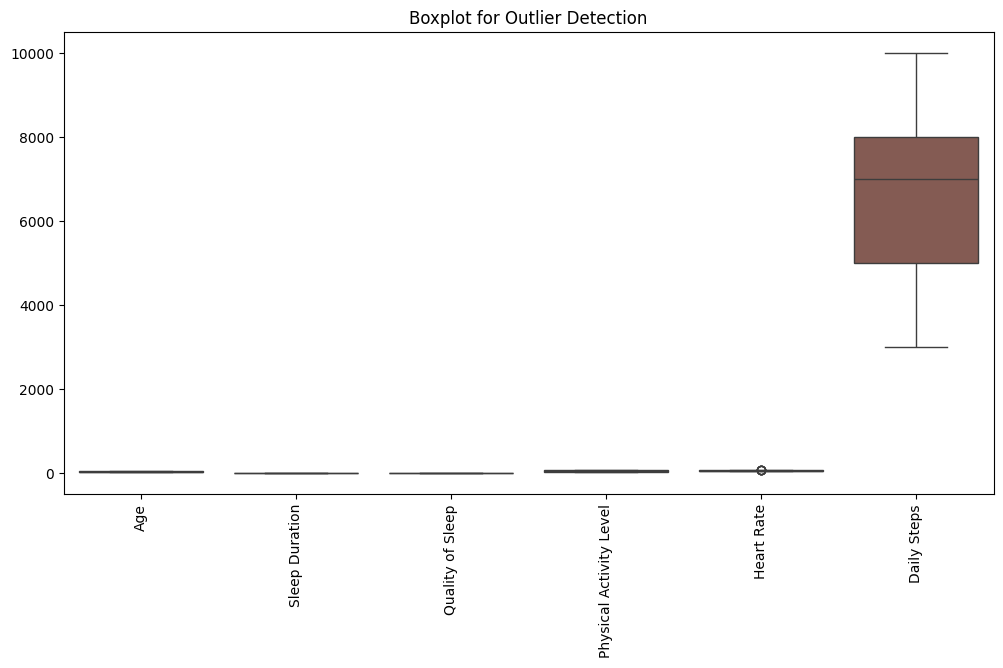

In [287]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

We notice a few outliers in the boxplot. Capping can be done to ensure the outliers do not affect the model.

We also notice that the ranges of some features are quite large compared to others. Standardization can be done later to make sure all features lie between -1 and 1.

In [288]:
## Capping outliers based on IQR for numerical columns
# for column in df.columns:
#     if column != 'stress_level':
#         Q1 = df[column].quantile(0.25)
#         Q3 = df[column].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_cap = Q1 - 1.5 * IQR
#         upper_cap = Q3 + 1.5 * IQR
#         df[column] = np.where(df[column] < lower_cap, int(lower_cap), df[column])
#         df[column] = np.where(df[column] > upper_cap, int(upper_cap), df[column])

# print("\nSummary of data after capping outliers:")
# df.describe()

# Select numeric columns

num_cols.remove('Stress Level')  

# Capping outliers
for column in num_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_cap = Q1 - 1.5 * IQR
    upper_cap = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_cap, lower_cap, df[column])
    df[column] = np.where(df[column] > upper_cap, upper_cap, df[column])

print("\nSummary of numeric data after capping outliers:")
print(df[num_cols].describe())


ValueError: list.remove(x): x not in list

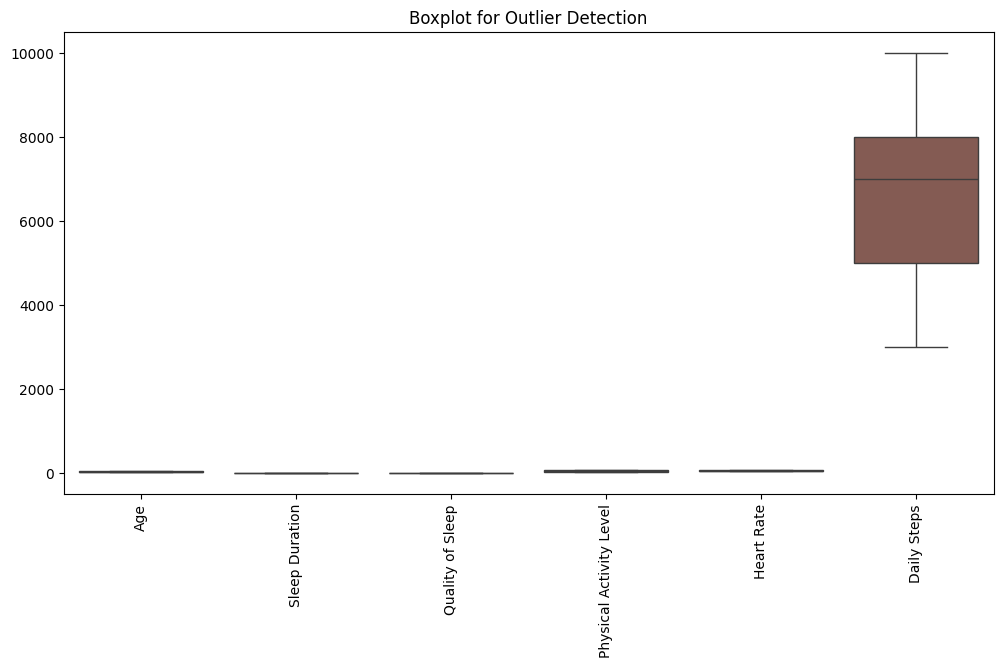

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

### Exploratory Data Analysis

#### Univariate Analysis

#### Numerical Features

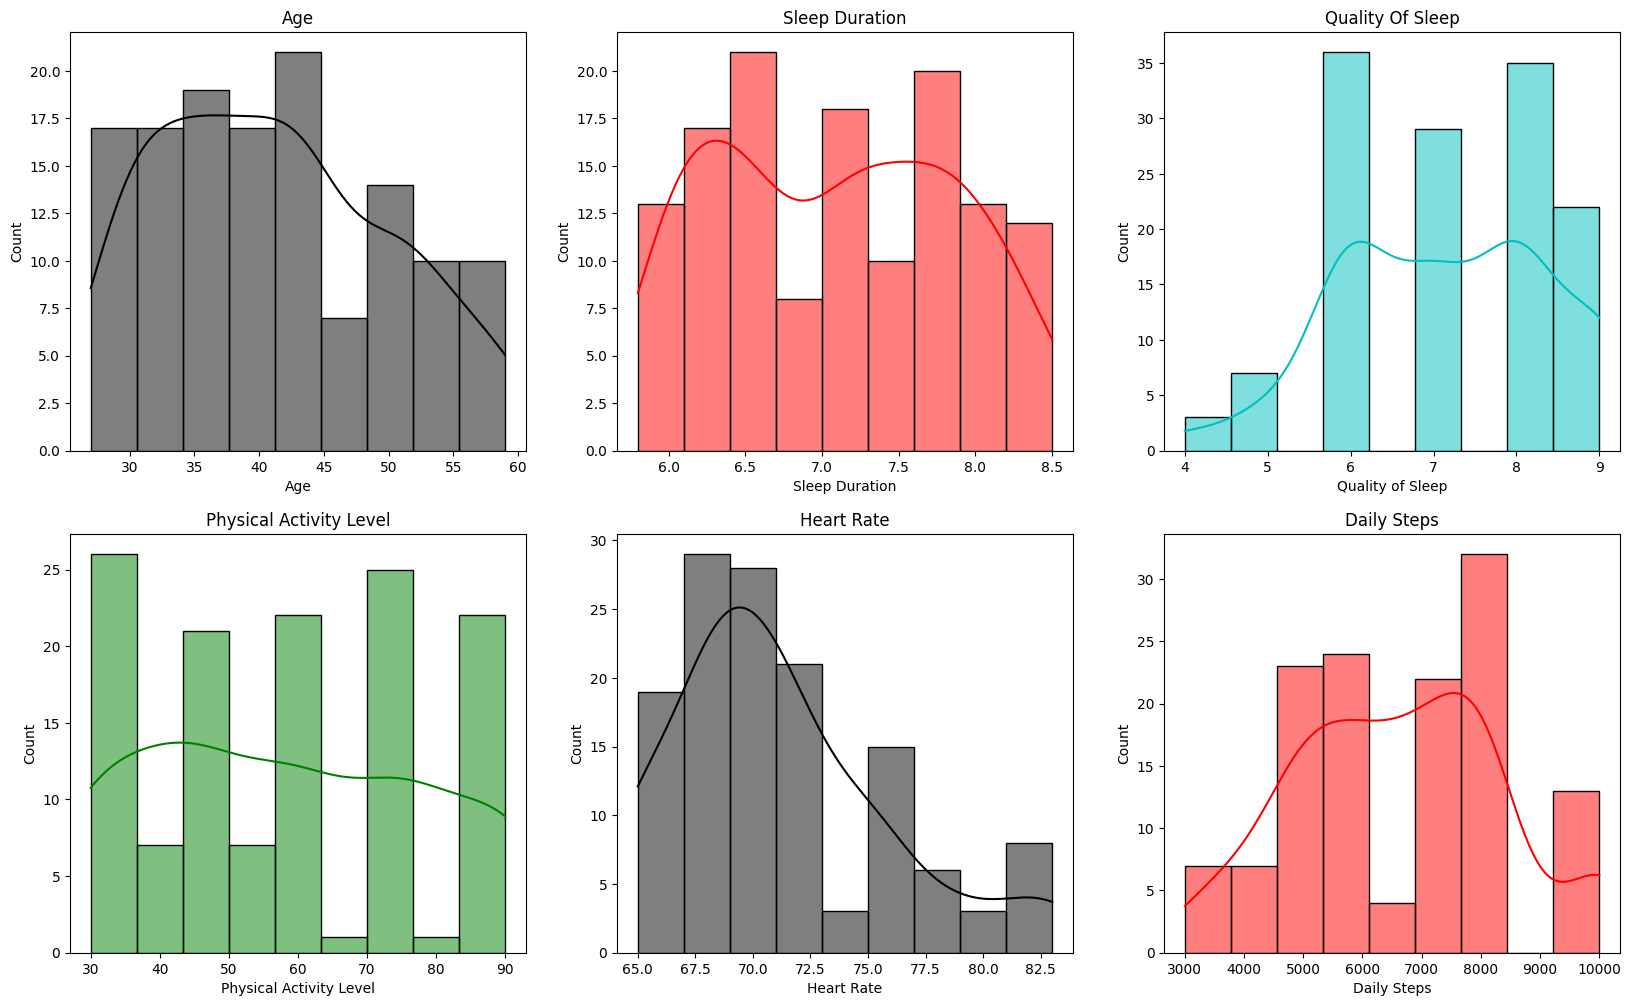

In [ ]:
colors = ['k', 'r', 'c', 'g']
plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.histplot(df[col], kde=True, color=colors[i % len(colors)])
plt.show()

#### Categorical Features

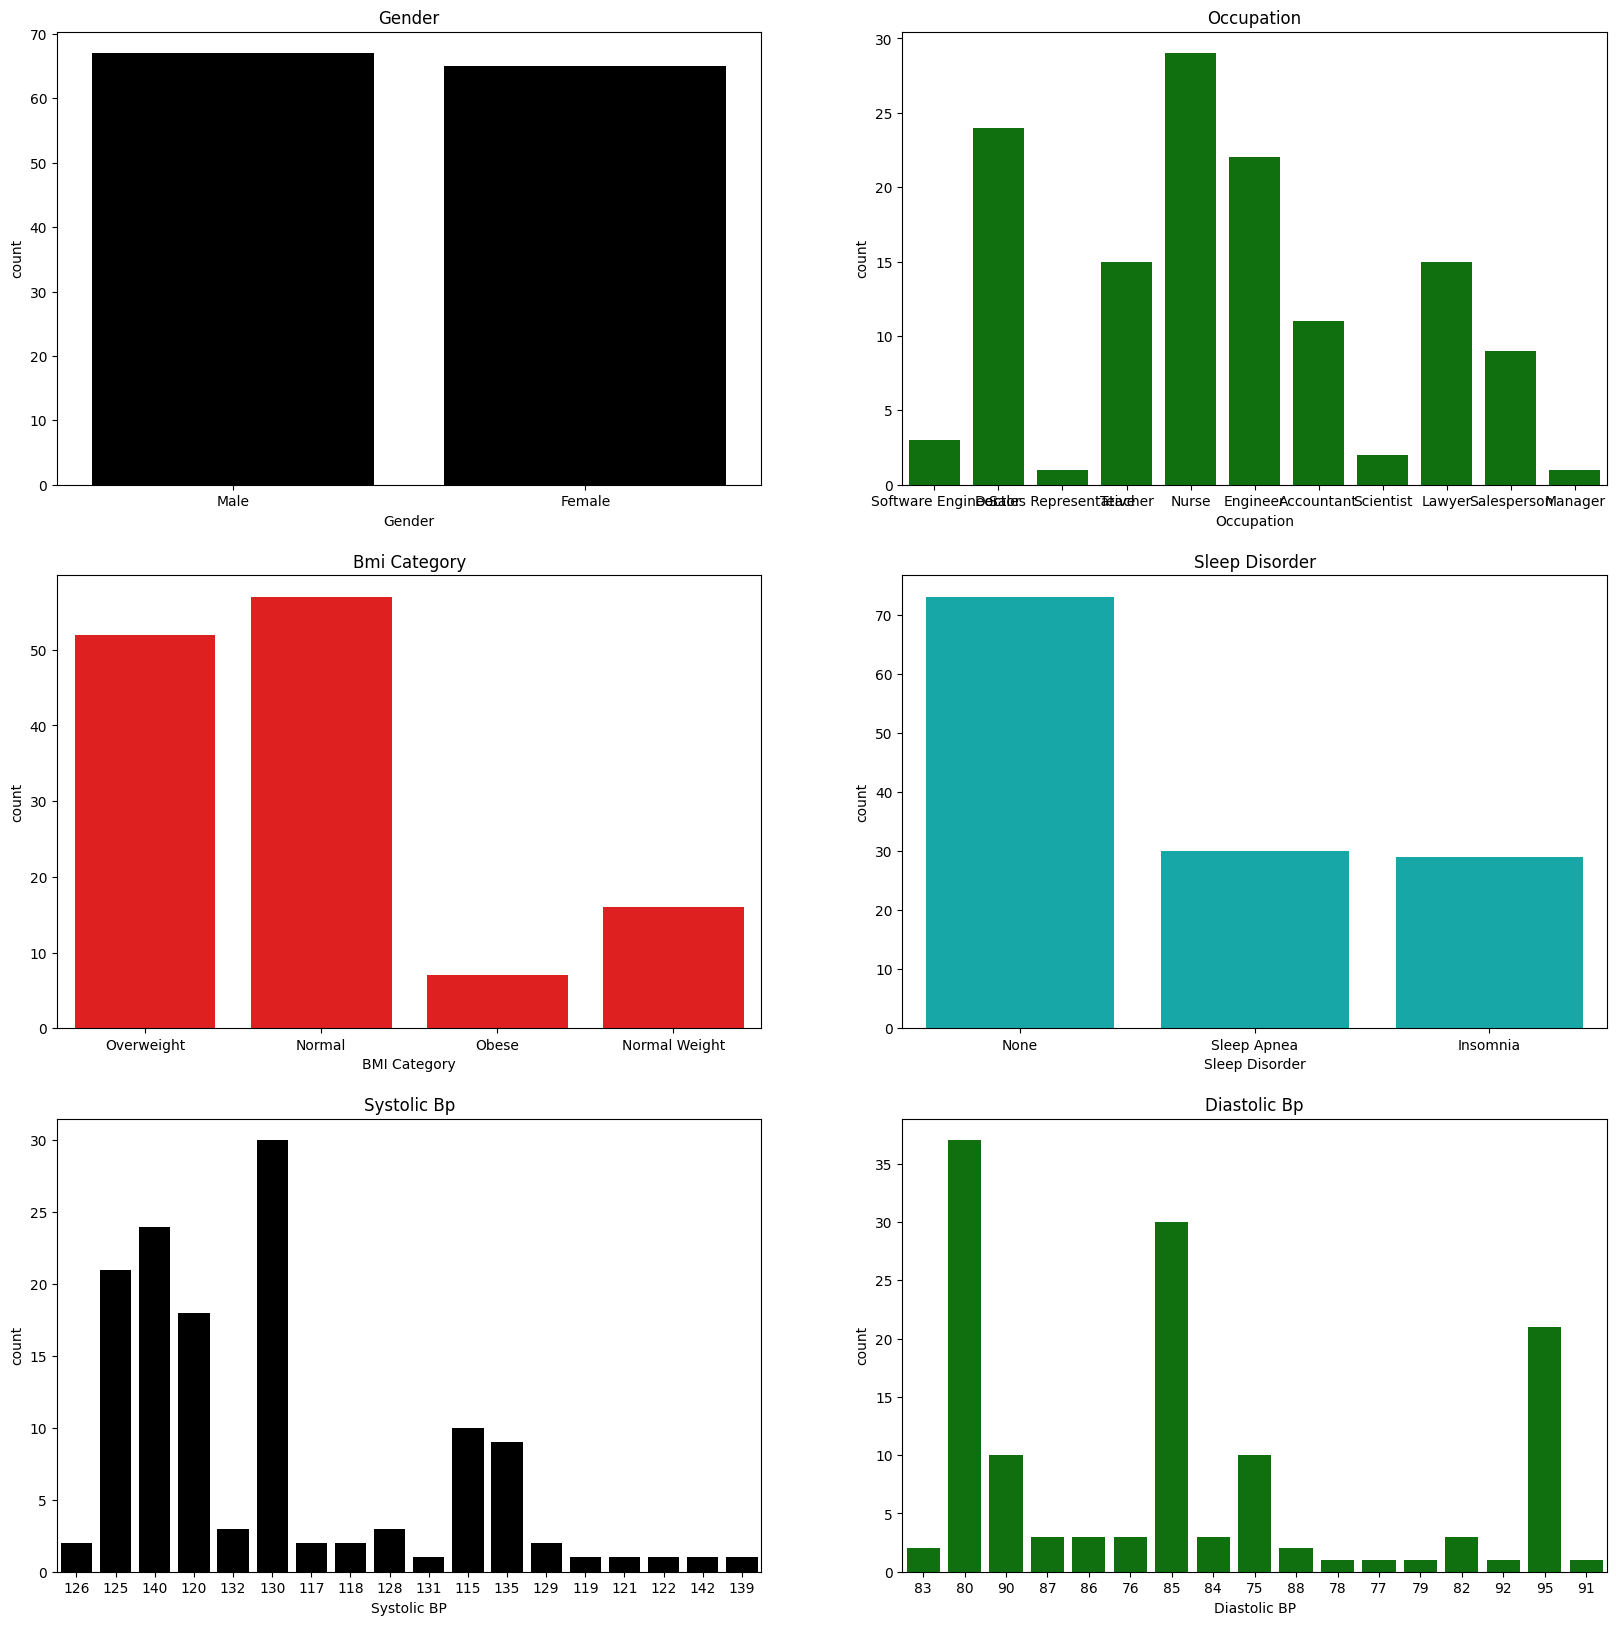

In [ ]:
colors = ['k', 'g', 'r', 'c']
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(3, 2, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
plt.show()

##### Distribution of classes of Target

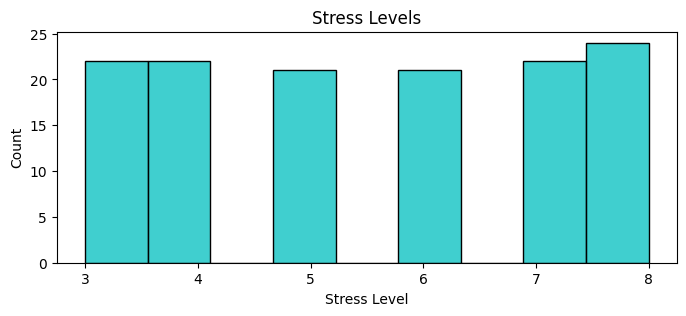

In [ ]:
plt.figure(figsize=(8, 3))
sns.histplot(x=df['Stress Level'], color='c')
plt.title('Stress Levels')
plt.show()

The dataset is slightly imbalanced because of the large number of data points in class 3 compared to the others.

#### Bivariate Analysis

#### Numerical Features

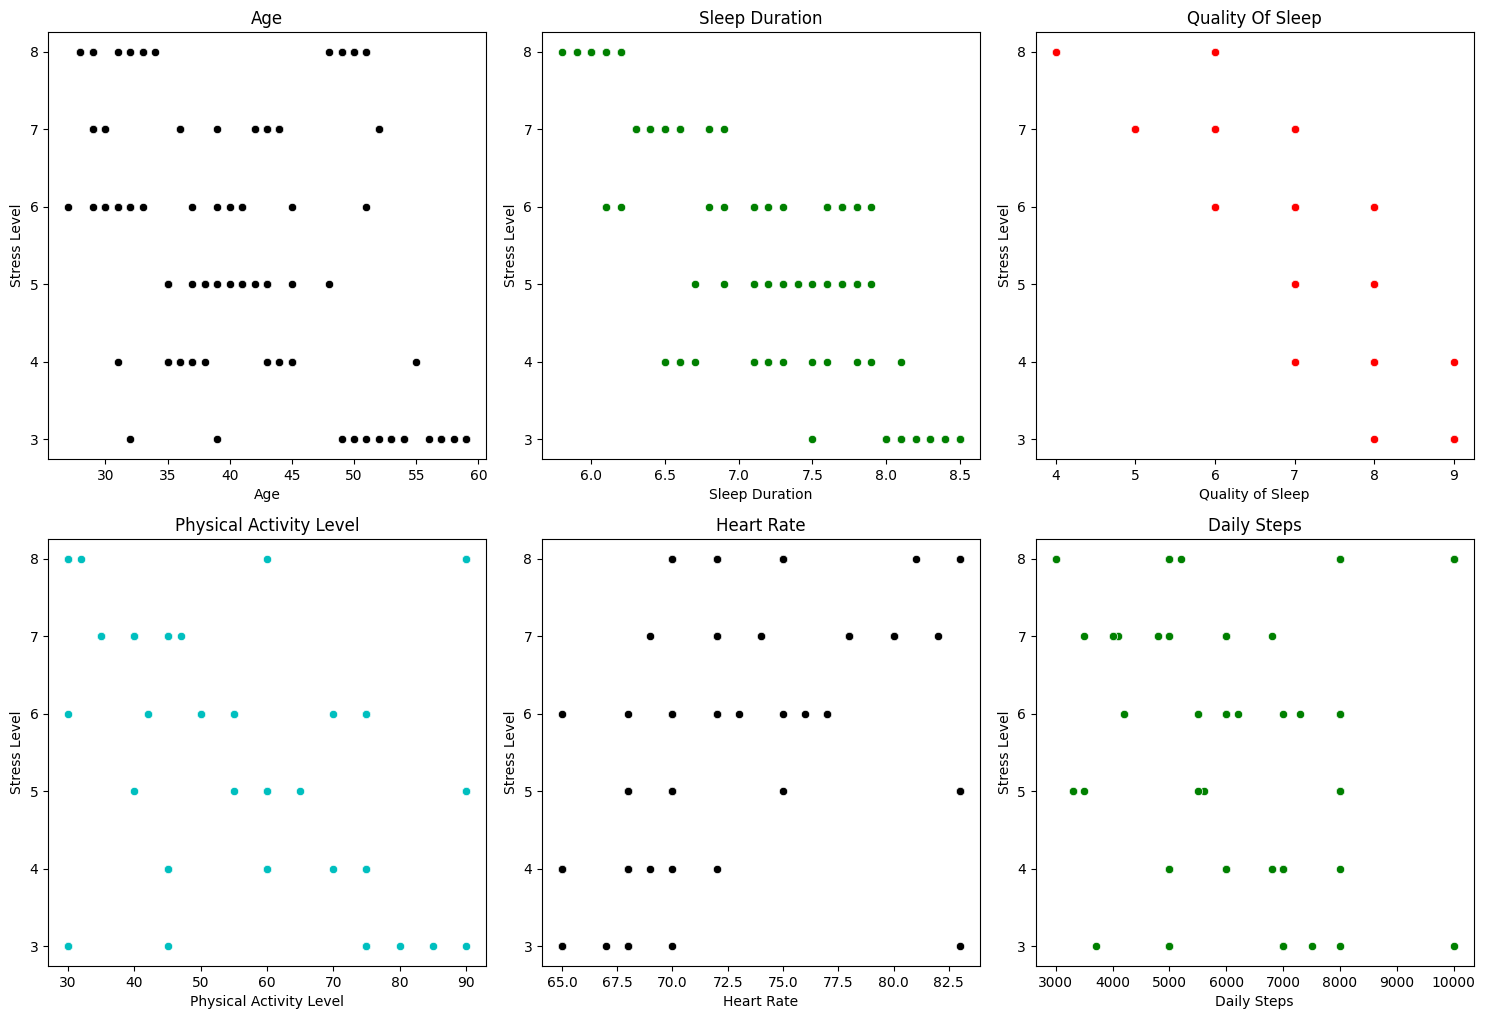

In [ ]:
# plotting count of each variable vs target
plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i+1)
    plt.title(" ".join(col.split('_')).title())
    sns.scatterplot(x=col, y='Stress Level', data=df, color=colors[i % len(colors)])
plt.tight_layout()
plt.show()

#### Categorical Features

ValueError: Could not interpret value `actual_productivity_score` for `y`. An entry with this name does not appear in `data`.

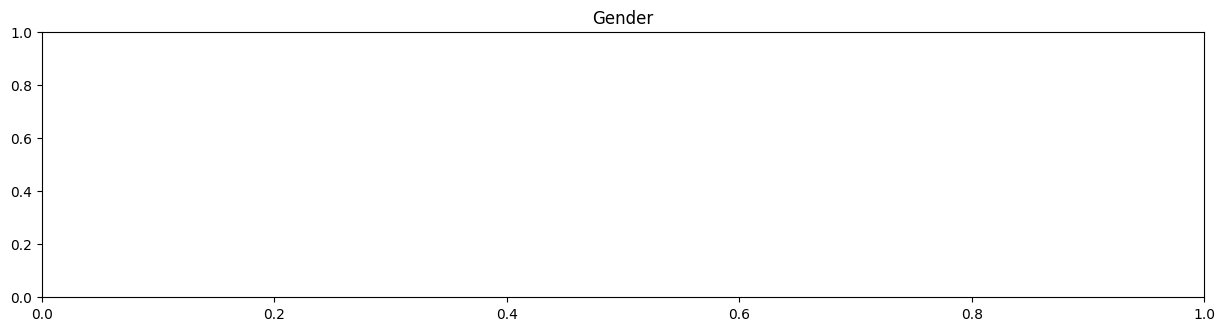

In [ ]:
# plotting violin plots of each feature vs target to see the data distribution against target for each feature 
palette = ['Set1', 'Set2', 'Set3', 'Paired', 'Accent', 'Pastel1', 'Pastel2', 'Dark2']
plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 1, i+1)
    plt.title(" ".join(col.split('_')).title())
    sns.boxplot(data=df, x=col, y='actual_productivity_score')
plt.tight_layout()
plt.show()

#### Multivariate Analysis

We plot the heatmap for the dataset to see the correlation between features

In [ ]:
num_cols.append('Stress Level')

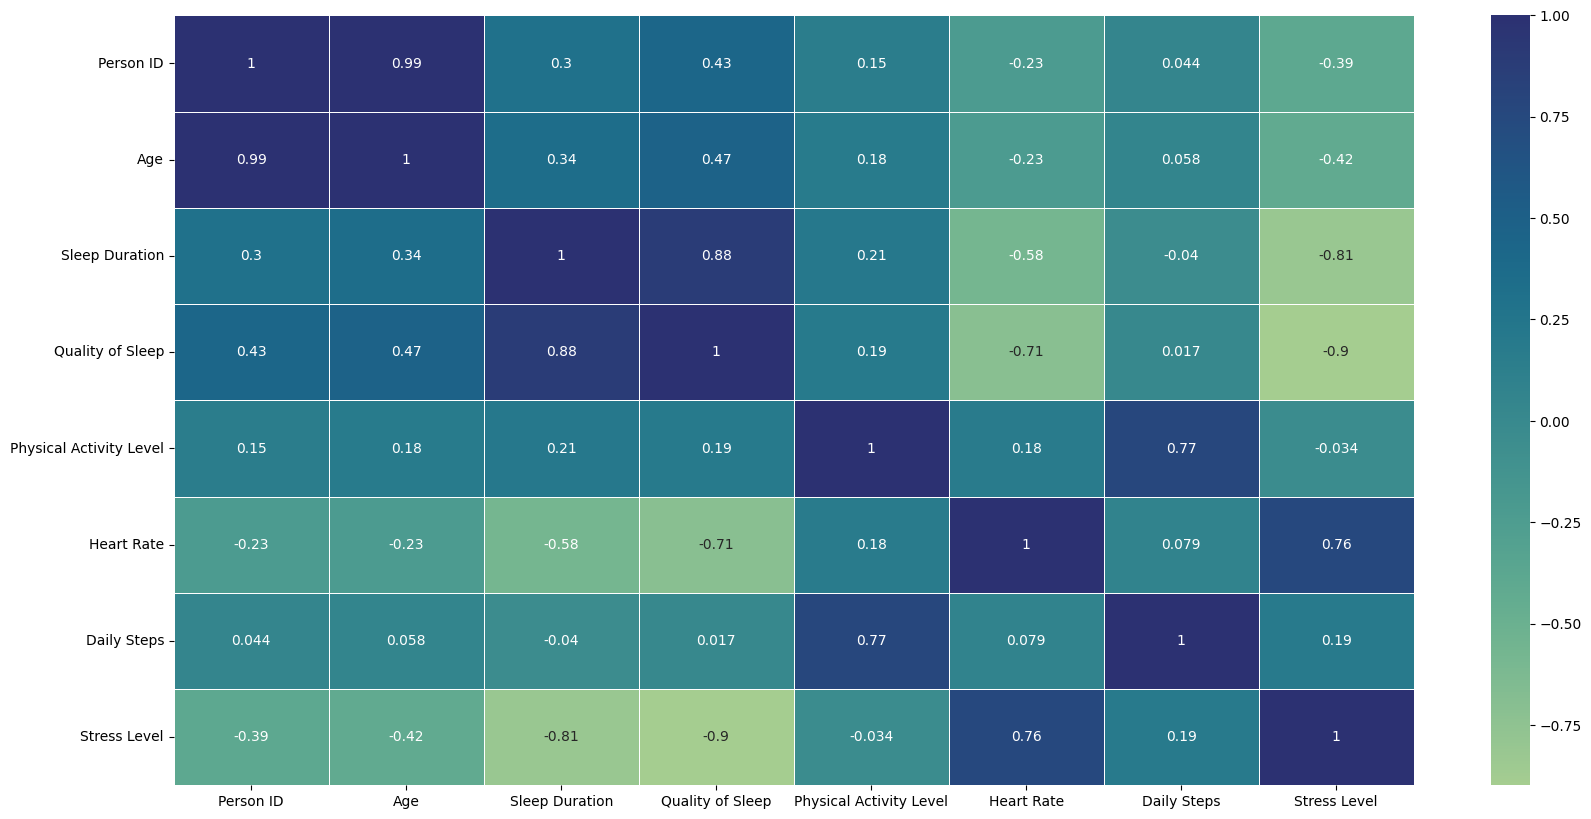

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(df[num_cols].corr(), annot=True, linewidth=0.5, cmap='crest')
plt.show()

It is seen that correlation between:<br>
perceived_productivity_score and actual_productivity_score ≈ 0.9 → very high correlation<br>
perceived_productivity_score and job_satisfaction_score ≈ 0.79<br>
actual_productivity_score and job_satisfaction_score ≈ 0.81<br>
We can keep only one among perceived_productivity_score, actual_productivity_score, job_satisfaction_score.<br>
<br>
According to feature importance scores:<br>
perceived_productivity_score      0.079735<br>
job_satisfaction_score            0.077128<br>
actual_productivity_score         0.075856)<br>
<br>
We are selecting perceived_productivity_score and removing the other two. 

In [ ]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1.0,Male,27.0,Software Engineer,6.1,6.0,42.0,6,Overweight,126/83,77.0,4200.0,Sleep Apnea
1,2.0,Male,28.0,Doctor,6.2,6.0,60.0,8,Normal,125/80,75.0,10000.0,Sleep Apnea
2,3.0,Male,28.0,Doctor,6.2,6.0,60.0,8,Normal,125/80,75.0,10000.0,Sleep Apnea
3,4.0,Male,28.0,Sales Representative,5.9,4.0,30.0,8,Obese,140/90,78.0,3000.0,Sleep Apnea
4,5.0,Male,28.0,Sales Representative,5.9,4.0,30.0,8,Obese,140/90,78.0,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370.0,Female,59.0,Nurse,8.1,9.0,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
370,371.0,Female,59.0,Nurse,8.0,9.0,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
371,372.0,Female,59.0,Nurse,8.1,9.0,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
372,373.0,Female,59.0,Nurse,8.1,9.0,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


In [ ]:
# df = df.drop(columns=['actual_productivity_score', 'job_satisfaction_score'])
# df

In [ ]:
# FIXME: One hot encoding???
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1.0,1,27.0,9,6.1,6.0,42.0,6,3,11,77.0,4200.0,1
1,2.0,1,28.0,1,6.2,6.0,60.0,8,0,9,75.0,10000.0,1
2,3.0,1,28.0,1,6.2,6.0,60.0,8,0,9,75.0,10000.0,1
3,4.0,1,28.0,6,5.9,4.0,30.0,8,2,22,78.0,3000.0,1
4,5.0,1,28.0,6,5.9,4.0,30.0,8,2,22,78.0,3000.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370.0,0,59.0,5,8.1,9.0,75.0,3,3,23,68.0,7000.0,1
370,371.0,0,59.0,5,8.0,9.0,75.0,3,3,23,68.0,7000.0,1
371,372.0,0,59.0,5,8.1,9.0,75.0,3,3,23,68.0,7000.0,1
372,373.0,0,59.0,5,8.1,9.0,75.0,3,3,23,68.0,7000.0,1


In [ ]:
# skew
df.skew().sort_values()

Sleep Disorder            -1.460651
Quality of Sleep          -0.207448
Blood Pressure            -0.181284
Gender                    -0.021478
Person ID                  0.000000
Sleep Duration             0.037554
Physical Activity Level    0.074487
Stress Level               0.154330
Daily Steps                0.178277
Age                        0.257222
BMI Category               0.284021
Heart Rate                 0.469312
Occupation                 0.745327
dtype: float64

In [ ]:
# FIXME: uses_focus_apps is highly skewed!

In [ ]:
# corr
num_cols = ['job_satisfaction_score', 'actual_productivity_score', 'age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours']
df[num_cols].corr()['actual_productivity_score'].sort_values()

days_feeling_burnout_per_month   -0.010554
daily_social_media_time          -0.007995
sleep_hours                      -0.007187
weekly_offline_hours             -0.005029
breaks_during_work               -0.004035
work_hours_per_day                0.000005
number_of_notifications           0.000213
coffee_consumption_per_day        0.001428
screen_time_before_sleep          0.002232
stress_level                      0.002728
age                               0.010155
job_satisfaction_score            0.809291
perceived_productivity_score      0.901342
actual_productivity_score         1.000000
Name: actual_productivity_score, dtype: float64

None of the features are correlated with the target

In [ ]:
# standardization
# FIXME: One Hot encoding and standardization????????
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
num_cols = ['Person ID',
 'Age',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Heart Rate',
 'Daily Steps']

for col in num_cols:
    df[col] = sc.fit_transform(np.array(df[col]).reshape(-1, 1))
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,-1.727426,1,-1.753096,9,-1.298887,-1.098280,-0.825418,6,3,11,1.974677,-1.619584,1
1,-1.718163,1,-1.637643,1,-1.173036,-1.098280,0.039844,8,0,9,1.413271,1.970077,1
2,-1.708901,1,-1.637643,1,-1.173036,-1.098280,0.039844,8,0,9,1.413271,1.970077,1
3,-1.699639,1,-1.637643,6,-1.550588,-2.771424,-1.402260,8,2,22,2.255380,-2.362273,1
4,-1.690376,1,-1.637643,6,-1.550588,-2.771424,-1.402260,8,2,22,2.255380,-2.362273,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,1.690376,0,1.941401,5,1.218127,1.411435,0.760896,3,3,23,-0.551649,0.113356,1
370,1.699639,0,1.941401,5,1.092276,1.411435,0.760896,3,3,23,-0.551649,0.113356,1
371,1.708901,0,1.941401,5,1.218127,1.411435,0.760896,3,3,23,-0.551649,0.113356,1
372,1.718163,0,1.941401,5,1.218127,1.411435,0.760896,3,3,23,-0.551649,0.113356,1


### Feature Selection/Extraction

In [ ]:
X=df.drop('Stress Level',axis=1)
y=df['Stress Level']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
192,0.050943,1,0.094153,7,-0.795484,-1.098280,-0.681208,3,15,0.571163,-0.505551,0
75,-1.032751,1,-1.060377,1,-1.424738,-1.098280,-1.402260,0,9,0.571163,-1.124458,1
84,-0.949390,1,-0.829471,9,0.463023,0.574864,0.039844,1,6,0.009757,0.732263,1
362,1.625540,0,1.941401,5,1.343978,1.411435,0.760896,3,23,-0.551649,0.113356,1
16,-1.579228,0,-1.522190,5,-0.795484,-1.934852,-0.921559,1,18,2.255380,-1.743365,1
...,...,...,...,...,...,...,...,...,...,...,...,...
71,-1.069800,1,-1.060377,1,-1.298887,-1.098280,-1.402260,0,9,0.571163,-1.124458,1
106,-0.745618,0,-0.598565,5,-1.298887,-1.098280,-0.825418,3,11,1.974677,-1.619584,1
270,0.773405,0,0.786871,5,-1.298887,-1.098280,1.481948,3,23,1.413271,1.970077,1
348,1.495867,0,1.710495,5,1.343978,1.411435,0.760896,3,23,-0.551649,0.113356,1


In [ ]:
X_train.shape

(24000, 18)

Train R²: 0.9963, RMSE: 0.1070, MAE: 0.0289
Test R²: 0.9908, RMSE: 0.1698, MAE: 0.0521


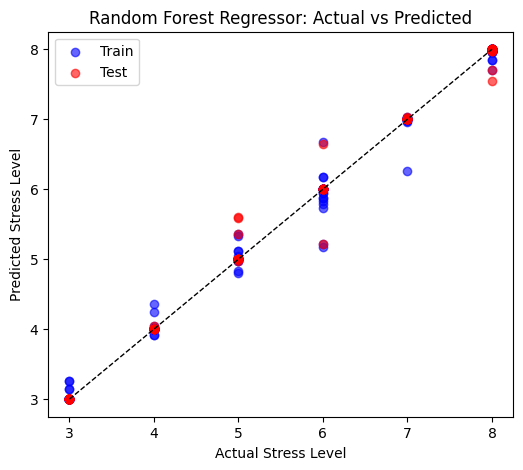

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use your selected features
X_train_r = X_train  # or X_train[final_features] if feature selection done
X_test_r = X_test

# Initialize and fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_r, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

# Compute regression metrics
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Train R²: {r2_train:.4f}, RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}")
print(f"Test R²: {r2_test:.4f}, RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}")

# Optional: visualize predicted vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue', label='Train')
plt.scatter(y_test, y_test_pred, alpha=0.6, color='red', label='Test')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', linewidth=1)  # perfect prediction line
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.title("Random Forest Regressor: Actual vs Predicted")
plt.legend()
plt.show()


Import necessary libraries needed for [erforming Logistic regression, Bayes classifers

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.metrics import accuracy_score,classification_report

### Logistic Regression


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", r2_score(y_test, y_pred_lr))
print("classification_report:", mean_squared_error(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9632941616436157
classification_report: 0.11467882724890617


### GaussianNB


In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("classification_report:",classification_report(y_test, y_pred_gnb))

GaussianNB Accuracy: 0.1655
classification_report:               precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       560
         2.0       0.00      0.00      0.00       577
         3.0       0.17      1.00      0.28       993
         4.0       0.00      0.00      0.00       549
         5.0       0.00      0.00      0.00       569
         6.0       0.15      0.00      0.01       572
         7.0       0.00      0.00      0.00       532
         8.0       0.00      0.00      0.00       534
         9.0       0.00      0.00      0.00       580
        10.0       0.00      0.00      0.00       534

    accuracy                           0.17      6000
   macro avg       0.03      0.10      0.03      6000
weighted avg       0.04      0.17      0.05      6000



/home/aadiuntu/ML_Project/Student_Stress_Level_Prediction_ML_Project_/.venv2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aadiuntu/ML_Project/Student_Stress_Level_Prediction_ML_Project_/.venv2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aadiuntu/ML_Project/Student_Stress_Level_Prediction_ML_Project_/.venv2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels

### CategoricalNB

In [ ]:
# Convert to numeric numpy arrays
X_train_np = X_train.to_numpy().astype(int)  # ensure integer type
X_test_np = X_test.to_numpy().astype(int)

#CAtegoricalNB cannot take negative input
X_train_cnb = X_train_np - X_train_np.min(axis=0)
X_test_cnb = X_test_np - X_train_np.min(axis=0) 
#for each element in X_test_cnb, it takes the min of value in the test set,the max value seen in x_train for that feature
X_test_cnb = np.minimum(X_test_cnb, X_train_cnb.max(axis=0))


cnb = CategoricalNB()
cnb.fit(X_train_cnb, y_train)
y_pred_cnb = cnb.predict(X_test_cnb)
print("CategoricalNB Accuracy:", accuracy_score(y_test, y_pred_cnb))
print("classification_report:",classification_report(y_test, y_pred_cnb))


CategoricalNB Accuracy: 0.1605
classification_report:               precision    recall  f1-score   support

         1.0       0.06      0.00      0.01       560
         2.0       0.10      0.01      0.02       577
         3.0       0.17      0.90      0.29       993
         4.0       0.11      0.01      0.02       549
         5.0       0.10      0.02      0.04       569
         6.0       0.11      0.02      0.04       572
         7.0       0.07      0.01      0.02       532
         8.0       0.17      0.01      0.02       534
         9.0       0.09      0.01      0.01       580
        10.0       0.08      0.02      0.04       534

    accuracy                           0.16      6000
   macro avg       0.11      0.10      0.05      6000
weighted avg       0.11      0.16      0.07      6000

